In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

pixsize = 33.02/512

In [3]:
profiles = pd.read_csv('https://raw.githubusercontent.com/OReyesMatte/MEDUSSA/refs/heads/main/Raw_Data/Fig1_Intensity_profiles.csv')

center = (np.min(profiles['Distance_(um)'])+np.max(profiles['Distance_(um)']))/2

x = (np.linspace(0,25,26)*pixsize)-center

ys = profiles.columns[2:]

/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_23416/2244734811.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(labels=xticks,fontsize=12, fontname="Arial")
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_23416/2244734811.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12, fontname="Arial")
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_23416/2244734811.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(labels=xticks,fontsize=12, fontname="Arial")
/var/folders/q6/szs86xgn755_g81_n0cyblxc0000gp/T/ipykernel_23416/2244734811.py:37: UserWarning: set_ticklabels() should only be used with a fix

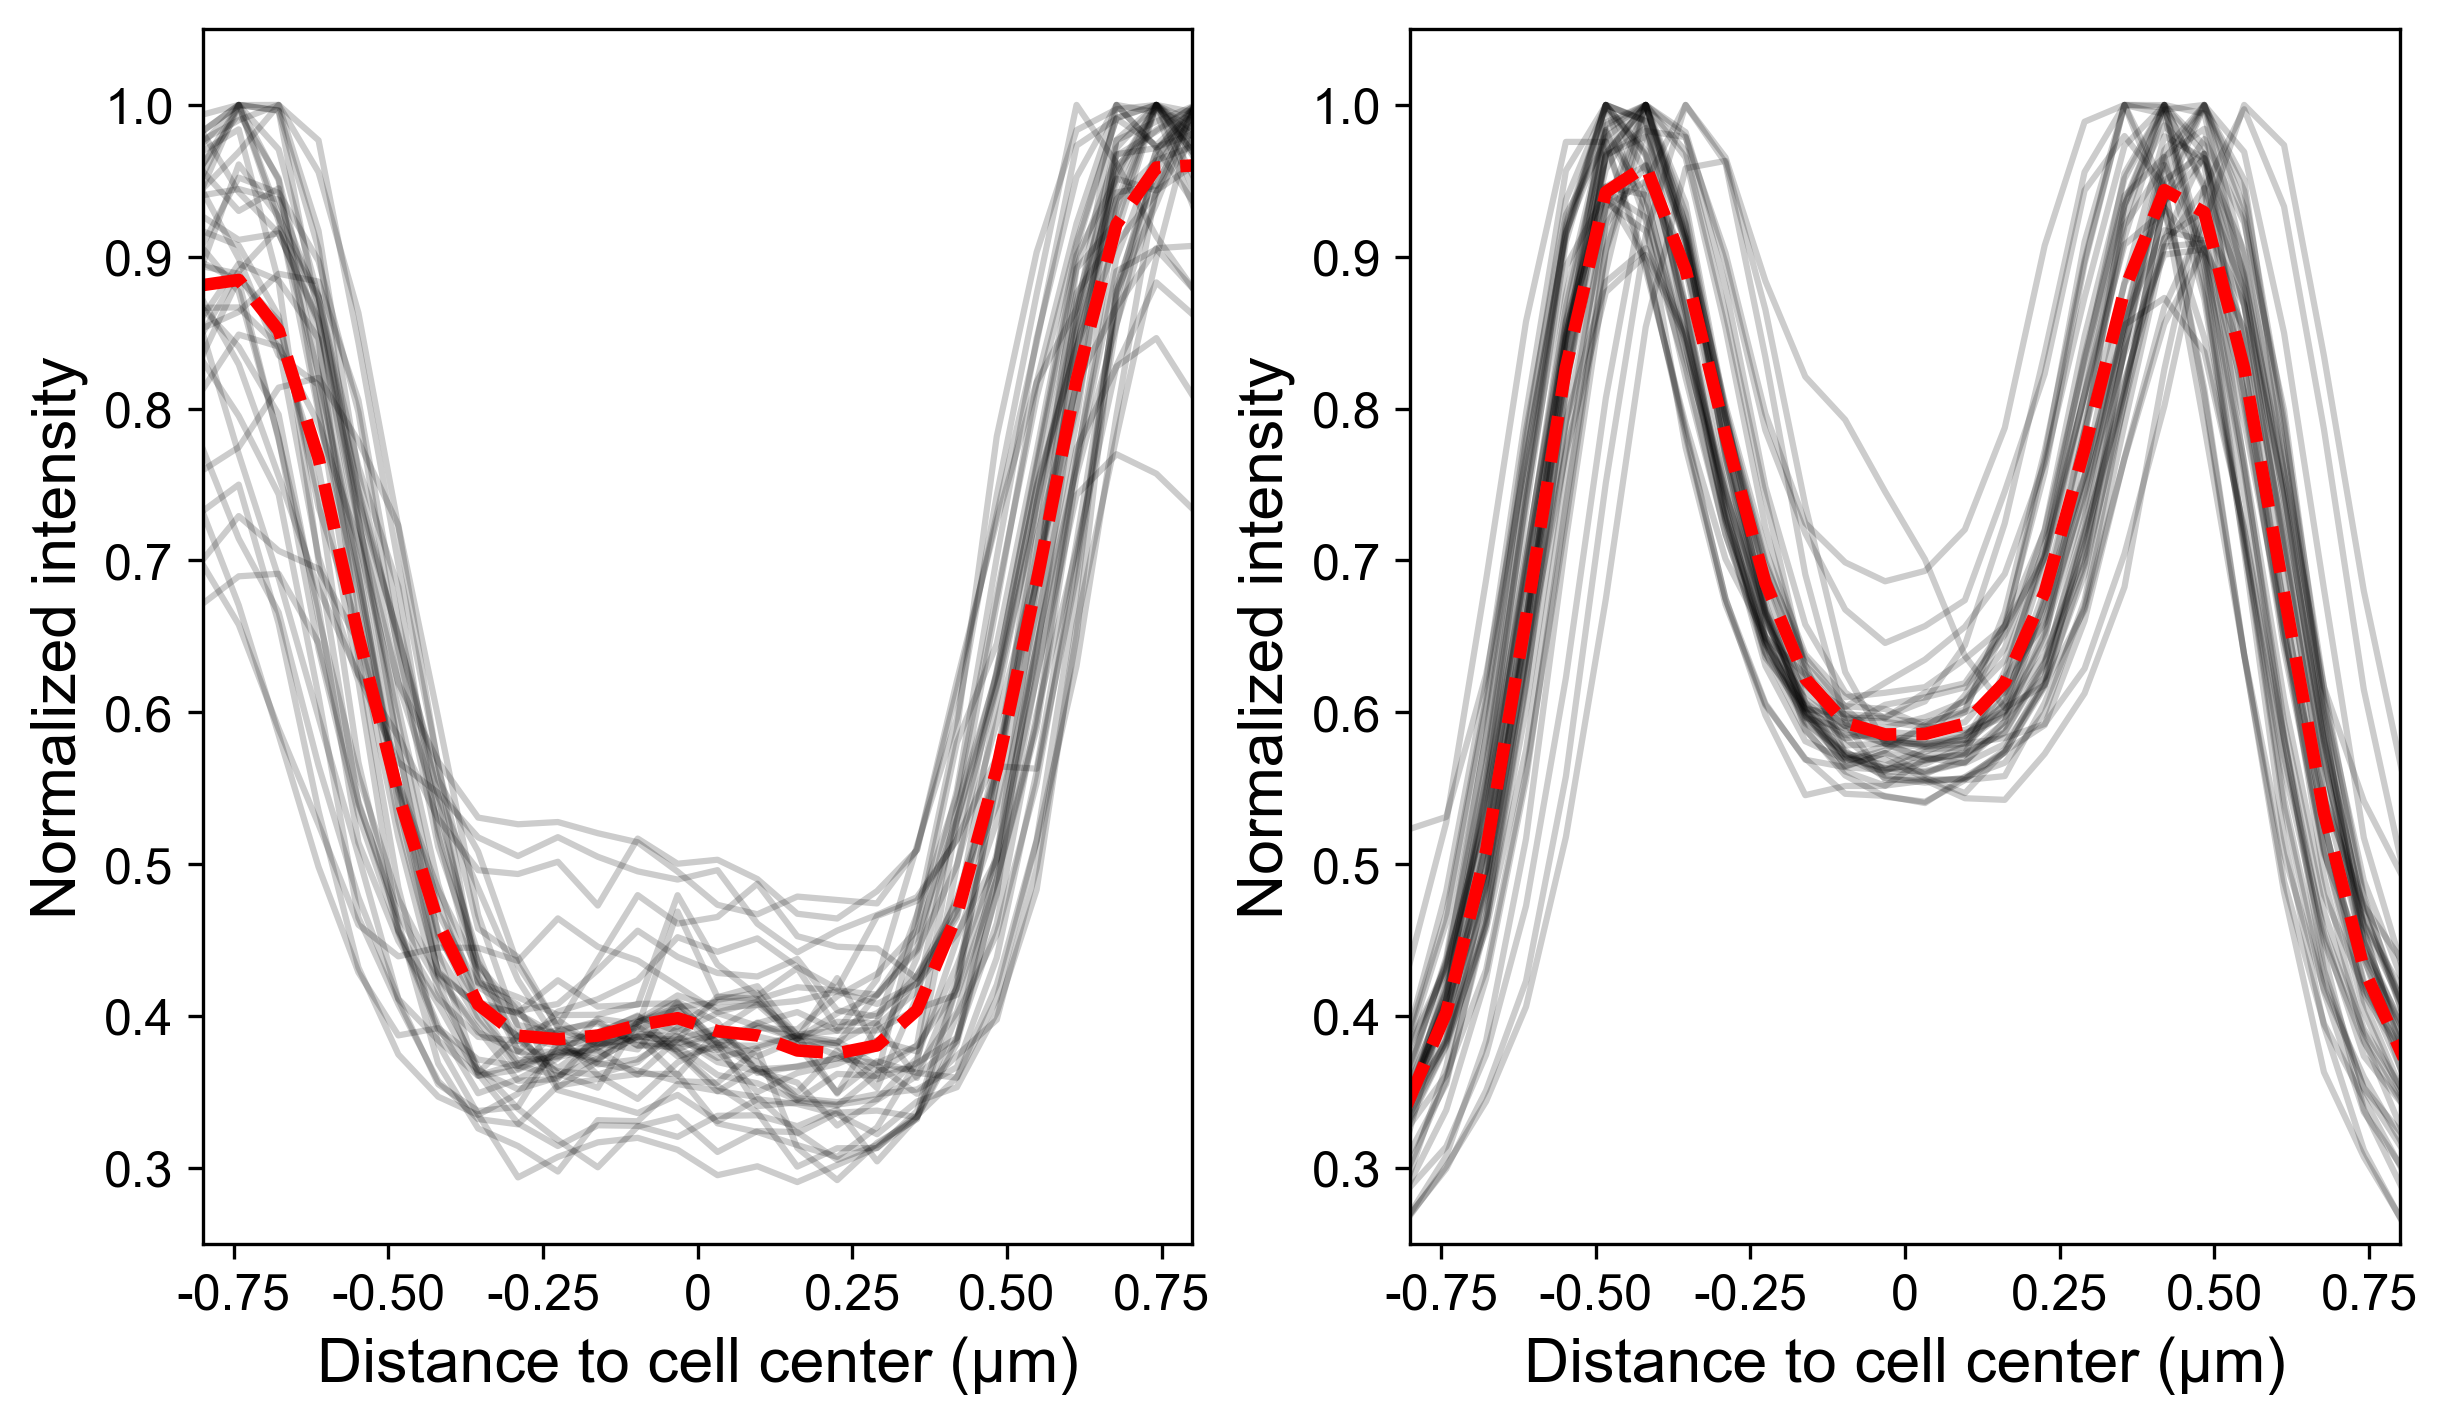

In [4]:
fig,ax = plt.subplots(dpi=300,figsize=(8.2,4.85),ncols=2)

xticks = ['','-0.75','-0.50','-0.25','0','0.25','0.50','0.75']

phase_vals = []
fm_vals = []

for y in ys:

    phase = np.array(profiles[profiles['Channel']=='Phase'][y])
    fm = np.array(profiles[profiles['Channel']=='FM'][y])

    phase = phase/phase.max()
    fm = fm/fm.max()
    
    phase_vals.append(phase)
    fm_vals.append(fm)
    
    ax[0].plot(x,phase,c='k',alpha=0.2)
    ax[1].plot(x,fm,c='k',alpha=0.2)

ax[0].plot(x,np.stack(phase_vals).mean(axis=0),c='r',linestyle='--',linewidth=3)
ax[1].plot(x,np.stack(fm_vals).mean(axis=0),c='r',linestyle='--',linewidth=3)

ax[0].set_xlabel('Distance to cell center (µm)',fontsize=15, fontname="Arial")
ax[0].set_ylabel('Normalized intensity',fontsize=15, fontname="Arial")
ax[0].set_xlim(-0.8,0.8)
ax[0].set_ylim(0.25,1.05)
ax[0].set_xticklabels(labels=xticks,fontsize=12, fontname="Arial")
ax[0].set_yticklabels(labels=ax[0].get_yticklabels(),fontsize=12, fontname="Arial")

ax[1].set_xlabel('Distance to cell center (µm)',fontsize=15, fontname="Arial")
ax[1].set_ylabel('Normalized intensity',fontsize=15, fontname="Arial")
ax[1].set_xlim(-0.8,0.8)
ax[1].set_ylim(0.25,1.05)
ax[1].set_xticklabels(labels=xticks,fontsize=12, fontname="Arial")
ax[1].set_yticklabels(labels=ax[1].get_yticklabels(),fontsize=12, fontname="Arial")

fig.tight_layout()
#fig.savefig('/Users/reyesmatte/Desktop/MEDUSSA_paper/Fig1/Profiles_revision.png')